In [27]:
from psd_tools import PSDImage

psd = PSDImage.open('mockups/mockup1.psd')  # change to your file name

print(f'Canvas size: {psd.width} x {psd.height}')
print('\nALL LAYERS:')

def print_layers(layers, indent=0):
    for layer in layers:
        print('  ' * indent + f'[{layer.kind}] "{layer.name}" — {layer.width}x{layer.height}')
        if hasattr(layer, '__iter__'):
            print_layers(layer, indent + 1)

print_layers(psd)

Canvas size: 6980 x 1080

ALL LAYERS:
[artboard] "Artboard 1" — 1080x1080
  [smartobject] "make_the_setting_202604072130" — 1148x1147
  [smartobject] "Asset 5@300x" — 203x68
  [smartobject] "POSTER HERE" — 252x334
  [smartobject] "POSTER HERE" — 327x438
[artboard] "Artboard 2" — 1080x1080
  [smartobject] "create_a_mockup_202604072131" — 1142x1142
  [smartobject] "Asset 5@300x" — 204x67
  [smartobject] "POSTER HERE" — 262x427
[artboard] "Artboard 3" — 1080x1080
  [smartobject] "make_the_poster_202604072200" — 1080x1080
  [smartobject] "Asset 5@300x" — 203x68
  [smartobject] "POSTER HERE" — 226x372
[artboard] "Artboard 4" — 1080x1080
  [smartobject] "change_the_wall_202604072139" — 1103x1103
  [smartobject] "Asset 5@300x" — 203x68
  [smartobject] "POSTER HERE" — 257x363
[artboard] "Artboard 5" — 1080x1080
  [smartobject] "create_a_mockup_202604072146" — 1080x1080
  [smartobject] "POSTER HERE" — 267x371
  [pixel] "Layer 1" — 2245x1014
  [shape] "Rectangle 1" — 807x142
  [type] "Print Size

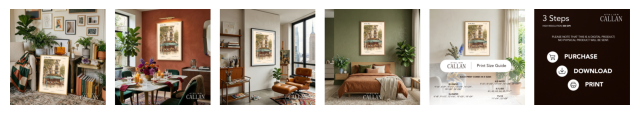

In [28]:
import matplotlib.pyplot as plt

img = psd.composite()
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
from psd_tools import PSDImage

psd = PSDImage.open('mockups/mockup1.psb')  # change to your file name

print("ALL LAYER NAMES IN THIS PSD:")
print("=" * 40)

def find_all_layers(layers, indent=0):
    for layer in layers:
        print(f"{'  ' * indent}👉 '{layer.name}'  [{layer.kind}]")
        if hasattr(layer, '__iter__'):
            find_all_layers(layer, indent + 1)

find_all_layers(psd)

ALL LAYER NAMES IN THIS PSD:
👉 'Rectangle 2'  [shape]
👉 'CAFE-03'  [smartobject]


Embedded image size: (1944, 2592)
Embedded image mode: RGB


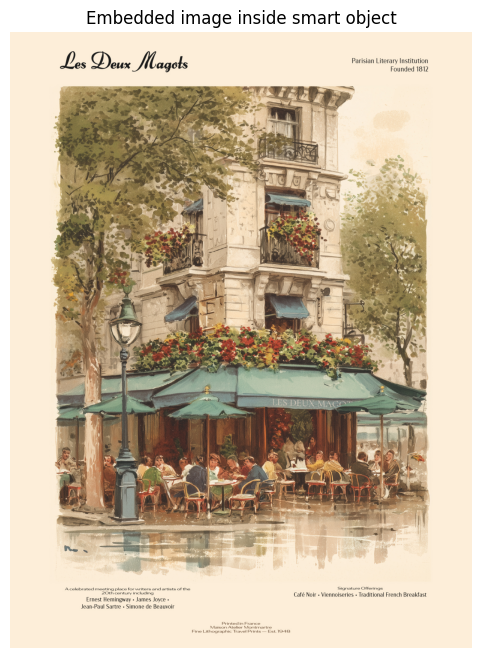

In [25]:
from psd_tools import PSDImage
from PIL import Image
import matplotlib.pyplot as plt
import io

psd = PSDImage.open('mockups/mockup1.psb')
TEST_ARTWORK = 'input/single/WB-EX-32-Edward_Robert_Hughes_Midsummer-18x24.jpg'  # change to your artwork file name

cafe_layer = list(psd)[1]

# Step 1 - Extract the embedded JPEG from inside the smart object
smart = cafe_layer.smart_object
raw_bytes = smart.data

# Step 2 - Open it as an image
embedded_img = Image.open(io.BytesIO(raw_bytes))
print(f'Embedded image size: {embedded_img.size}')
print(f'Embedded image mode: {embedded_img.mode}')

# Show it
plt.figure(figsize=(6, 8))
plt.imshow(embedded_img)
plt.title('Embedded image inside smart object')
plt.axis('off')
plt.show()